In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_LAYERS = 11
with open(f"Results/rollout_local/{N_LAYERS}layers/attn_matrices{N_LAYERS}layers.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

attn_list = [attn_matrices[key]['attn_matrix'] for key in attn_matrices.keys()]

In [3]:
def normalize_with_residual(A):
    """
    A: shape (d, d), row-stochastic attention matrix.

    Returns:
        A_hat = row_normalize(I + A)
    """
    d = A.shape[0]
    A_tilde = np.eye(d) + A
    return A_tilde / A_tilde.sum(axis=1, keepdims=True)


def compute_z_evolution(A_layers, X_test, datum_idx):
    """
    Computes z^(ell) for one test datum.

    Parameters
    ----------
    A_layers : list of arrays
        A_layers[ell] has shape (N, d, d).

    X_test : array
        Test data, shape (N, d).

    datum_idx : int
        Index of the selected test datum.

    Returns
    -------
    Z : array
        Shape (L + 1, d), where Z[0] = x and
        Z[ell] = A_hat^(ell) Z[ell - 1].
    """

    x = X_test[datum_idx].copy()
    z = x.copy()

    Z = [z]

    for A_all in A_layers:
        A = A_all[datum_idx]              # shape (d, d)
        A_hat = normalize_with_residual(A)

        z = A_hat @ z
        Z.append(z.copy())

    return np.array(Z)


def plot_z_evolution(Z, feature_names=None, top_k=None):
    """
    Plots layer-wise evolution of z^(ell).

    Z has shape (L + 1, d).
    """

    L_plus_1, d = Z.shape
    layers = np.arange(L_plus_1)

    if top_k is not None:
        scores = np.max(np.abs(Z), axis=0)
        idx = np.argsort(scores)[::-1][:top_k]
    else:
        idx = np.arange(d)

    plt.figure(figsize=(10, 6))

    for j in idx:
        label = feature_names[j] if feature_names is not None else f"feature {j}"
        plt.plot(layers, Z[:, j], marker="o", linewidth=1.5, label=label)

    plt.xlabel("Layer")
    plt.ylabel(r"$z^{(\ell)}$")
    plt.title(r"Layer-wise evolution of $z^{(\ell)} = \widehat A^{(\ell)} z^{(\ell-1)}$")
    plt.grid(True, alpha=0.3)

    if top_k is not None:
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

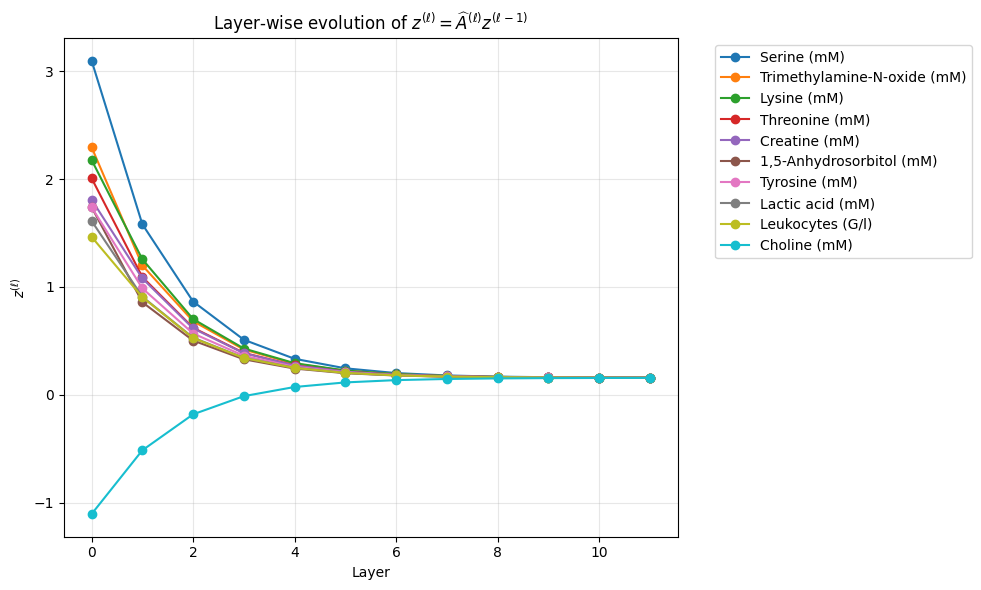

In [4]:
test_data = np.load("data_processed/test_data_scaled.npz")
X_test = test_data["x"]    

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

# Example usage
datum_idx = 10

Z = compute_z_evolution(
    A_layers=attn_list,
    X_test=X_test,
    datum_idx=datum_idx
)

plot_z_evolution(
    Z,
    feature_names=feature_names,
    top_k=10
)